<a href="https://colab.research.google.com/github/HMS-Cleveland/Questionary_logist/blob/my/%E9%9D%9E%E7%BA%BF%E6%80%A7%E9%80%BB%E8%BE%91%E5%9B%9E%E5%BD%92_%E9%99%84%E5%B8%A62%E4%B8%AA%E6%82%A3%E7%99%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- 4.1 Kernel SHAP (Log-Odds Base) ---


  0%|          | 0/50 [00:00<?, ?it/s]

Kernel SHAP 耗时: 5.39 s

--- 5. 归一化 K-Additive SHAP (k=2) ---
  正在计算归一化 k=2 additive SHAP...


k=2 Normalized:   0%|          | 0/50 [00:00<?, ?it/s]

k=2 Normalized 耗时: 57.89 s

--- 全局重要性对比 (Mean |SHAP| Log-Odds 空间) ---
--- Kernel SHAP vs. 归一化 k=2 附加性 SHAP ---
                             Kernel  k=2 Normalized
menopause                   0.12425         0.11609
age_5_years                 0.19762         0.18388
BIRADS_breast_density       0.28850         0.28117
ethnic                      0.62866         0.68083
bmi                         0.26956         0.22210
first_birth                 0.27827         0.24595
num_of_first_degree_cancer  0.38411         0.38473
breast_surgery              0.19737         0.21074
hormone_therapy             0.14195         0.11658

--- 差异百分比 (期望值较低) ---
menopause                      6.56
age_5_years                    6.95
BIRADS_breast_density          2.54
ethnic                         8.30
bmi                           17.61
first_birth                   11.62
num_of_first_degree_cancer     0.16
breast_surgery                 6.78
hormone_therapy               17.87
Name: Difference %, dt

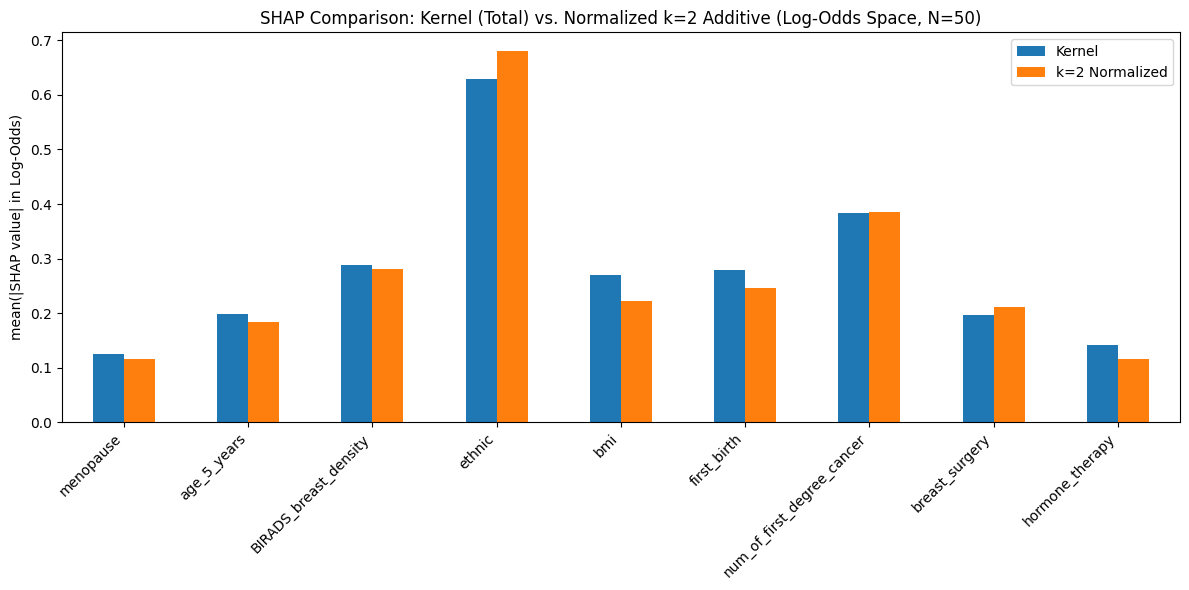

In [3]:
# =============== 0. 基础库与依赖 ===============
!pip install -q shap

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import time
import warnings
from itertools import combinations
from math import factorial
from joblib import Parallel, delayed
from tqdm.auto import tqdm

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

# 忽略部分警告
warnings.filterwarnings("ignore")

# ==================================================================
# 1. 数据加载与预处理 (保持不变)
# ==================================================================
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

FILE_PATH = '/content/drive/MyDrive/公开数据集/risk.txt'

try:
    data = pd.read_csv(FILE_PATH, sep=r'\s+', header=None, usecols=usecols, names=names)
except FileNotFoundError:
    print(f"❌ 错误：找不到文件 {FILE_PATH}")
    raise

# --- 清洗与构造标签 ---
cols_with_missing_9 = ['menopause', 'BIRADS_breast_density', 'ethnic', 'bmi',
                       'first_birth', 'num_of_first_degree_cancer',
                       'breast_surgery', 'hormone_therapy']
data_processed = data.copy()
for col in cols_with_missing_9:
    data_processed[col] = data_processed[col].replace(9, 'unknown').astype(str)
data_processed['age_5_years'] = data_processed['age_5_years'].astype(str)
data_processed['diagnosis'] = (data_processed['diagnosis_12'] | data_processed['diagnosis_13']).astype(int)
data_processed = data_processed.drop(columns=['diagnosis_12', 'diagnosis_13'])

# --- 数据分割 ---
X = data_processed.drop(columns=['diagnosis'])
y = data_processed['diagnosis']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

# --- 定义特征名称和数量 ---
feature_names = X.columns.tolist()
M = len(feature_names)

# ==================================================================
# 2. 模型训练与 Log-Odds 预测函数
# ==================================================================
ordinal_features = ['age_5_years', 'BIRADS_breast_density', 'bmi', 'num_of_first_degree_cancer']
nominal_features = ['ethnic', 'first_birth']
binary_features = ['menopause', 'breast_surgery', 'hormone_therapy']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal', OneHotEncoder(handle_unknown='ignore', drop=None), nominal_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features),
    ],
    remainder='passthrough'
)

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        penalty='l2', C=0.008, solver='lbfgs', max_iter=5000,
        class_weight='balanced', random_state=42
    ))
])
model_pipeline.fit(X_train, y_train)

# 定义 Log-Odds 预测函数
def pred_fn_log_odds(X_input):
    if isinstance(X_input, np.ndarray):
        X_input = pd.DataFrame(X_input, columns=feature_names)
    return model_pipeline.decision_function(X_input)

# ==================================================================
# 3. SHAP 准备工作
# ==================================================================
N_SHAP_SAMPLE = 50
X_global = X_test.sample(N_SHAP_SAMPLE, random_state=123)
COMMON_BG = X_train.sample(100, random_state=42)
bg_df_vals = COMMON_BG.copy()

shapley_mat = {}
times = {}

# ==================================================================
# 4. Kernel SHAP 计算 (基准)
# ==================================================================
print("\n--- 4.1 Kernel SHAP (Log-Odds Base) ---")
start = time.time()
explainer_k = shap.KernelExplainer(pred_fn_log_odds, COMMON_BG, link='identity')
shapley_mat['Kernel'] = explainer_k.shap_values(X_global, nsamples=100)
times['Kernel'] = time.time() - start
print(f"Kernel SHAP 耗时: {times['Kernel']:.2f} s")


# ==================================================================
# 5. K-Additive SHAP 计算 (引入归一化因子)
# ==================================================================

# K-additive SHAP 函数 (基于 Log-Odds 空间，使用归一化边际贡献求和)
def k_additive_shap_normalized(xser, k=2):
    phis = np.zeros(M)
    total_weight_sum = 0.0 # 用于计算归一化因子

    for i in range(M):
        # 最大子集大小为 k-1
        max_size = min(k - 1, M - 1)

        current_feature_weight_sum = 0.0

        for size in range(0, max_size + 1):
            other_features_indices = [j for j in range(M) if j != i]

            for S_indices in combinations(other_features_indices, size):
                S_cols = [feature_names[j] for j in S_indices]
                i_col = feature_names[i]

                # SHAP 权重
                weight = factorial(len(S_cols)) * factorial(M - len(S_cols) - 1) / factorial(M)

                # 权重求和 (只在第一个特征 i 处累加总权重和，防止重复计数)
                if i == 0:
                    total_weight_sum += weight * M

                # 累加当前特征的权重和
                current_feature_weight_sum += weight

                # 构造数据
                X_S = bg_df_vals.copy()
                X_Si = bg_df_vals.copy()

                # 掩码操作 (DataFrame 赋值)
                for col in S_cols:
                    val = xser[col]
                    X_S[col] = val
                    X_Si[col] = val

                # 加上 i 特征
                X_Si[i_col] = xser[i_col]

                # 预测 (使用 Log-Odds 预测函数)
                f_S = pred_fn_log_odds(X_S).mean()
                f_Si = pred_fn_log_odds(X_Si).mean()

                phis[i] += weight * (f_Si - f_S)

        # 归一化因子：1 / (边际贡献所占的权重和)
        # 必须确保 current_feature_weight_sum > 0
        if current_feature_weight_sum > 1e-9:
             # 将低阶边际贡献放大至相当于 100% 权重
            phis[i] = phis[i] / current_feature_weight_sum

    return phis

def compute_k_additive(X_sample, k):
    print(f"  正在计算归一化 k={k} additive SHAP...")
    start_k = time.time()
    res = Parallel(n_jobs=4)(
        delayed(k_additive_shap_normalized)(X_sample.iloc[i], k=k)
        for i in tqdm(range(len(X_sample)), desc=f'k={k} Normalized')
    )
    return np.array(res), time.time() - start_k

print("\n--- 5. 归一化 K-Additive SHAP (k=2) ---")
shapley_mat['k=2 Normalized'], times['k=2 Normalized'] = compute_k_additive(X_global, k=2)

print(f"k=2 Normalized 耗时: {times['k=2 Normalized']:.2f} s")

# ==================================================================
# 6. 结果数值对比
# ==================================================================
global_imp = {k: np.abs(v).mean(0) for k, v in shapley_mat.items()}
df_global = pd.DataFrame(global_imp, index=feature_names)

print('\n--- 全局重要性对比 (Mean |SHAP| Log-Odds 空间) ---')
print("--- Kernel SHAP vs. 归一化 k=2 附加性 SHAP ---")
print(df_global.round(5))

# 计算差异百分比
df_global['Difference %'] = (np.abs(df_global['Kernel'] - df_global['k=2 Normalized']) / df_global['Kernel']) * 100

print("\n--- 差异百分比 (期望值较低) ---")
print(df_global['Difference %'].round(2))

# 绘图
df_global[['Kernel', 'k=2 Normalized']].plot(kind='bar', figsize=(12, 6))
plt.title(f'SHAP Comparison: Kernel (Total) vs. Normalized k=2 Additive (Log-Odds Space, N={N_SHAP_SAMPLE})')
plt.ylabel('mean(|SHAP value| in Log-Odds)')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

12和13关系诊断报告

1. 交叉表（行=12，列=13）：
        13=0  13=1      总计
12=0  271355  2114  273469
12=1       0  7191    7191
总计    271355  9305  280660

2. 关键诊断指标：
   - 样本总数: 280660
   - 13=1的样本数: 9305
   - 12=1的样本数: 7191
   - ❗ 包含率 (13=1 → 12=1): 77.3%

3. 关系自动诊断：
   ❌ 部分重叠关系（包含率=77.3%）
   解释：两变量相关但独立

4. 关键证据样本（13=1但12=0，共2114个）：
      age_5_years  num_of_first_degree_cancer  BIRADS_breast_density
832             1                           1                      2
1993            1                           0                      3
2257            1                           0                      3


/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3287774315.py:90: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missi

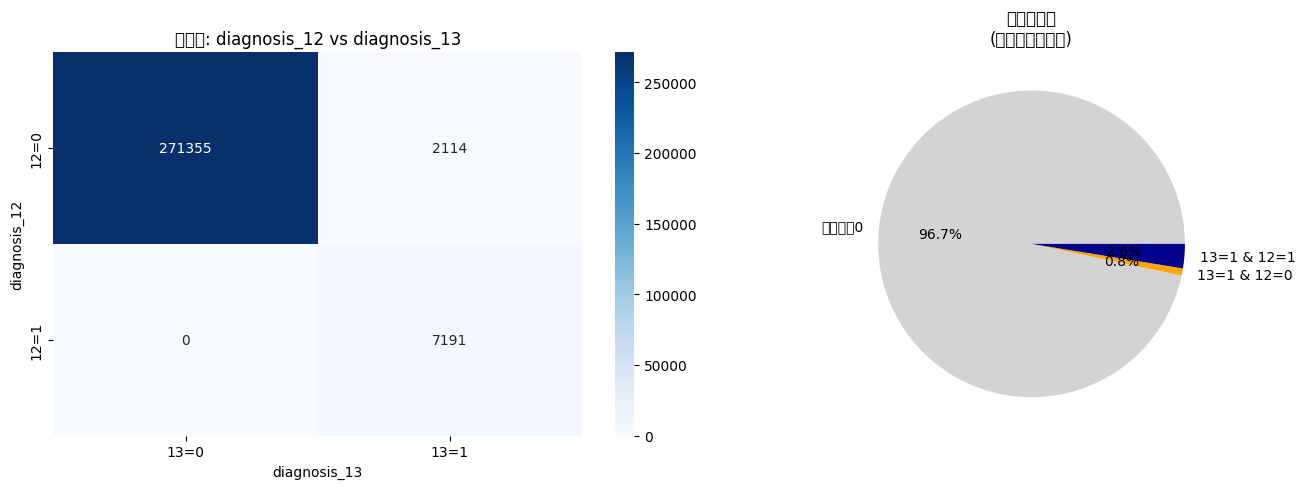


最终决策建议
❌ 数据问题：12和13不是包含关系，需重新定义数据字典


In [ ]:
# ==================== 诊断12和13关系的完整代码 ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 读取原始数据（不处理标签，保留原始状态）
usecols = [0, 1, 2, 3, 5, 6, 7, 8, 11, 12, 13]
names = ['menopause', 'age_5_years', 'BIRADS_breast_density', 'ethnic', 'bmi',
         'first_birth', 'num_of_first_degree_cancer', 'breast_surgery',
         'hormone_therapy', 'diagnosis_12', 'diagnosis_13']

data = pd.read_csv('/content/drive/MyDrive/公开数据集/risk.txt',
                   sep=r'\s+', header=None, usecols=usecols, names=names)

print("="*60)
print("12和13关系诊断报告")
print("="*60)

# 2. 构建核心诊断工具：交叉表
cross_tab = pd.crosstab(
    data['diagnosis_12'],
    data['diagnosis_13'],
    margins=True,
    margins_name='总计'
)
cross_tab.index = ['12=0', '12=1', '总计']
cross_tab.columns = ['13=0', '13=1', '总计']
print("\n1. 交叉表（行=12，列=13）：")
print(cross_tab)

# 3. 计算关键指标：包含率和互斥率
total_samples = len(data)
cancer_13 = data['diagnosis_13'] == 1
cancer_12 = data['diagnosis_12'] == 1

# 黄金指标：当13=1时，12也=1的比例
containment_rate = (cancer_13 & cancer_12).sum() / cancer_13.sum()
print(f"\n2. 关键诊断指标：")
print(f"   - 样本总数: {total_samples}")
print(f"   - 13=1的样本数: {cancer_13.sum()}")
print(f"   - 12=1的样本数: {cancer_12.sum()}")
print(f"   - ❗ 包含率 (13=1 → 12=1): {containment_rate:.1%}")

# 4. 自动判断关系类型
print(f"\n3. 关系自动诊断：")
if containment_rate == 1.0:
    print("   ✅ 完全包含关系")
    print("   解释：13是12的超集（13包含12）")
    print("   建议：13=浸润性癌+DCIS, 12=仅浸润性癌")
elif containment_rate > 0.95:
    print(f"   ⚠️ 近似包含关系（包含率={containment_rate:.1%}）")
    print("   建议：检查剩余{cancer_13.sum() - (cancer_13 & cancer_12).sum()}个样本是否为数据错误")
elif containment_rate > 0.5:
    print(f"   ❌ 部分重叠关系（包含率={containment_rate:.1%}）")
    print("   解释：两变量相关但独立")
else:
    print(f"   ❌ 无包含关系（包含率={containment_rate:.1%}）")
    print("   解释：12和13是独立变量")

# 5. 证据性样本抽查（如果存在互斥样本）
mutual_exclusion = (cancer_13 & ~cancer_12)
if mutual_exclusion.sum() > 0:
    print(f"\n4. 关键证据样本（13=1但12=0，共{mutual_exclusion.sum()}个）：")
    examples = data[mutual_exclusion].head(3)
    print(examples[['age_5_years', 'num_of_first_degree_cancer', 'BIRADS_breast_density']])
else:
    print(f"\n4. 关键证据：不存在13=1且12=0的样本")

# 6. 可视化关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 6.1 交叉表热力图
sns.heatmap(cross_tab.iloc[:-1, :-1], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('交叉表: diagnosis_12 vs diagnosis_13')
axes[0].set_xlabel('diagnosis_13')
axes[0].set_ylabel('diagnosis_12')

# 6.2 包含关系示意图
labels = ['两者都为0', '13=1 & 12=0', '13=1 & 12=1']
sizes = [
    (~cancer_13 & ~cancer_12).sum(),
    mutual_exclusion.sum(),
    (cancer_13 & cancer_12).sum()
]
colors = ['lightgray', 'orange', 'darkblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('关系示意图\n(橙色区域是关键)')

plt.tight_layout()
plt.show()

# 7. 最终决策建议
print("\n" + "="*60)
print("最终决策建议")
print("="*60)
if containment_rate == 1.0:
    decision = "✅ 采用方案：13=患癌（总标签），12=浸润性癌（亚型）"
    print(decision)
    print("   后续分析：在患癌人群中，用12区分浸润性癌和DCIS")
elif containment_rate > 0.95:
    print("⚠️ 需人工核查例外样本后，再决定标签定义")
else:
    print("❌ 数据问题：12和13不是包含关系，需重新定义数据字典")